# EPL Match Prediction using XGBoost
This notebook trains an XGBoost model on the tabular Premier League dataset. Gradient Boosting is naturally suited for tabular data and will likely establish a strong baseline or outperform complex neural networks on this specific task.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('final_dataset.csv')

df['TotalGoals'] = df['FTHG'] + df['FTAG']
df['GoalDiff']   = df['FTHG'] - df['FTAG']

# explicit feature differentials
df['Points_Diff'] = df['HTP'] - df['ATP']
df['Form_Diff'] = df['HTFormPts'] - df['ATFormPts']
df['GD_Diff'] = df['HTGD'] - df['ATGD']

# Target: home win binary
df['FTR_binary'] = (df['FTR'] == 'H').astype(int)

In [2]:
features = [
    # Block 1: Home Form & Overall Performance
    'HTP', 'HTFormPts', 'HTGD', 'HTWinStreak3', 'HTWinStreak5', 'HTLossStreak3',
    # Block 2: Home Offensive & Defensive Stats
    'HTGS', 'HTGC',
    # Block 3: Away Form & Overall Performance
    'ATP', 'ATFormPts', 'ATGD', 'ATWinStreak3', 'ATWinStreak5', 'ATLossStreak3',
    # Block 4: Away Offensive & Defensive Stats
    'ATGS', 'ATGC',
    # Block 5: Head-to-Head / Differentials
    'DiffPts', 'DiffFormPts',
    'Points_Diff', 'Form_Diff', 'GD_Diff'
]

X = df[features]
y = df['FTR_binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, shuffle=False)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.15, shuffle=False)

print(f"Train size: {len(X_train)}")
print(f"Val size: {len(X_val)}")
print(f"Test size: {len(X_test)}")

Train size: 4941
Val size: 873
Test size: 1026


In [3]:
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    early_stopping_rounds=15
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=20
)


[0]	validation_0-logloss:0.68359
[20]	validation_0-logloss:0.64041
[40]	validation_0-logloss:0.63328
[60]	validation_0-logloss:0.63421
[63]	validation_0-logloss:0.63418


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=15,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

Accuracy: 0.6608187134502924
F1 Score: 0.583732057416268

Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.79      0.71       552
           1       0.67      0.51      0.58       474

    accuracy                           0.66      1026
   macro avg       0.66      0.65      0.65      1026
weighted avg       0.66      0.66      0.65      1026



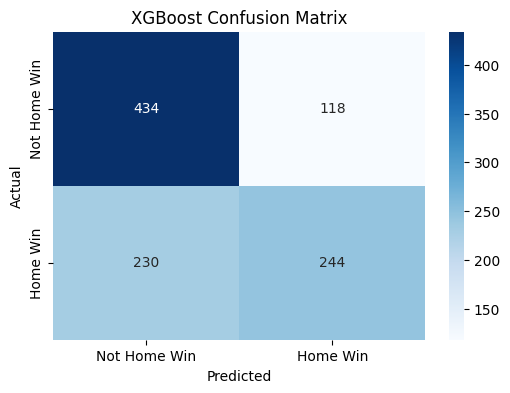

In [4]:
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Home Win', 'Home Win'], yticklabels=['Not Home Win', 'Home Win'])
plt.title('XGBoost Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

<Figure size 1000x800 with 0 Axes>

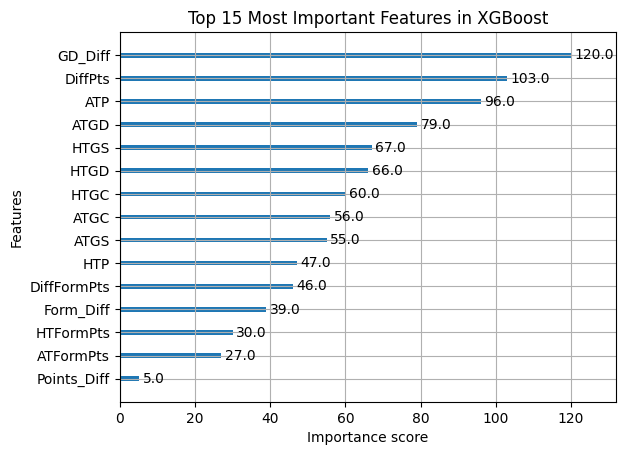

In [5]:
# Feature Importance
plt.figure(figsize=(10, 8))
xgb.plot_importance(xgb_model, importance_type='weight', max_num_features=15)
plt.title('Top 15 Most Important Features in XGBoost')
plt.show()

In [6]:
xgb_model.save_model('epl_xgboost_model.json')

from google.colab import files
files.download('epl_xgboost_model.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>